# Control theory. Course introduction.

## TP1. System modeling. State-space representation of dynamical systems.

## Study load

Course grade breakdown:

    Labs - 40%
    
    Final project presentation 30%

    Final test 30%
    
File name for lab submission: yourname_labnumber.ipynb (example: elenavanneaux_TP1.ipynb)    

The completed notebooks should be **submitted via the corresponding Moodle assignments before the beginning of the next session.**

## Prerequisites for practice
### Math
During the course, we will cover the following areas of mathematics:
    
    1. Linear Algebra

    2. Calculus

    3. Differential equations

    4. Dynamics (Mechanics and Physics)

### Python programming
In the labs we will use a Python programming language and the following libraries:

    1. NumPy https://numpy.org/doc/stable/

    2. SciPy https://docs.scipy.org/doc/scipy/

    3. Matplotlib https://matplotlib.org/stable/tutorials/index

    4. SymPy https://docs.sympy.org/latest/tutorials/intro-tutorial/intro.html

### Jupyter Notebook Markdown Cells Documentation

Please check on Markdown cells documentation, to provide a fancy look for your notebooks!

https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html

## Ex.1: Vehicle Suspension System

Vehicle Suspension System

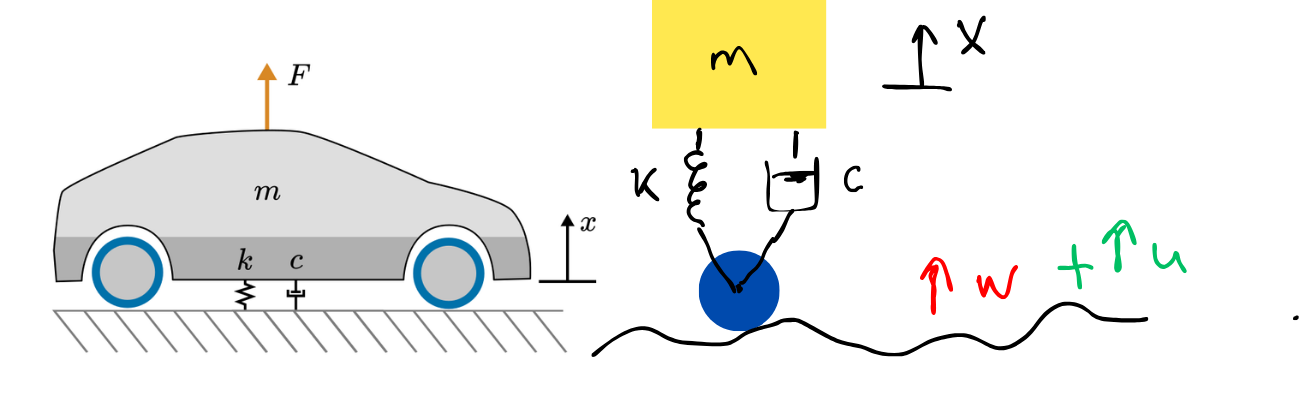

with the following system parameters:

    (m) mass 1.0 kg

    (k) spring constant 5.0 N/m

    $(c)$ damping constant 2 Ns/m

### **Equation of Motion:**

For a mass-spring-damper system, the equation of motion can be derived using Newton's second law or by applying the principles of dynamics. The general form of the equation is:

$$
m \frac{d^2x}{dt^2} + c \frac{dx}{dt} + kx = u + w
$$

### **State-Space Representation:**

To convert the second-order differential equation into a system of first-order differential equations, we introduce the following state variables:
- Let $ x_1 = x $ (position),
- Let $ x_2 = \dot x $ (velocity).

The system becomes:

$$\dot x = Ax+Bu+Dw$$

where
state vector $x = (position, velocity)$, and state and control matrices are the following:
$$ A = \begin{pmatrix} 0&1\\ -\frac{k}{m}&-\frac{c}{m}\end{pmatrix},\ B = \begin{pmatrix} 0\\ \frac{1}{m} 
\end{pmatrix},\ D =\begin{pmatrix} 0\\ \frac{1}{m} 
\end{pmatrix}$$

## TODO

Today we will study the dynamic of a passive suspension system, i.e. we assume that there is no active control ($u =0,$ for all $t>0$). 

1. Check on the code below, what kind of situation does it model?

Modify the code below to analyse how the suspension system will work on different roads.

answer: the initial code models Free Vibration with Initial Conditions. 
Since u=0 and w=0, the system only moves if it starts with an initial displacement

2. Let disturbance input $w(t)$ be given by a step function
    $$w = \left\{\begin{aligned}
        &0, \quad t <3.0\\
        &1.0,  \quad 3.0 \leq t < 7.0\\
        &0,  \quad t \geq 7
    \end{aligned}\right.$$
   How will it affect the behavior of the system? What kind of road scenario is modeled with step function disturbance?

-Answer:When t=3, the mass will suddenly experience a constant upward force. 
   It will overshoot, oscillate slightly, and settle at a new higher position. Like drivingthrough a bump.

When t=7, the force disappears, and the mass will oscillate back down to zero
3. How will the system behavior change when we assume that there is no damper in the system (i.e., c=0)?
-Answer: it will oscillate indefinitely without settling down

4. Now assume that the system is disturbed by a sinusoidal input $w = sin(t)$.
   How will it affect the behavior of the system? What kind of road profile does a sinusoidal input describe?
   Answer: A sinusoidal disturbance w = sin(t) causes the system to oscillate at the forcing frequency.
    If the forcing frequency matches the system's natural frequency, resonance occurs, and the system will experience very large oscillations.

In [15]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# x is a state vector, t is a current time, A is a dynamic matrix, B is a control matrix, D is a disturbance matrix, 
# u_func(t) is a control input, w_func(t) is a disturbance input 
def StateSpace(x, t, A, B, D, u_func, w_func):
    w = w_func(t)
    u = u_func(t)
    # Flatten u and w for proper matrix operations
    return np.dot(A, x) + np.dot(B, u).flatten() + np.dot(D, w).flatten()

# OpenLoopInputOutputSystem with time-dependent w(t)
def OpenLoopInputOutputSystem(A, B, D, C, R, u_func, w_func, T, x0):
    # Solve the ODE system with odeint, passing the time-dependent w function
    solution = odeint(StateSpace, x0, T, args=(A, B, D, u_func, w_func))
    # Output calculation using C and the solution
    return (C @ solution.T)    

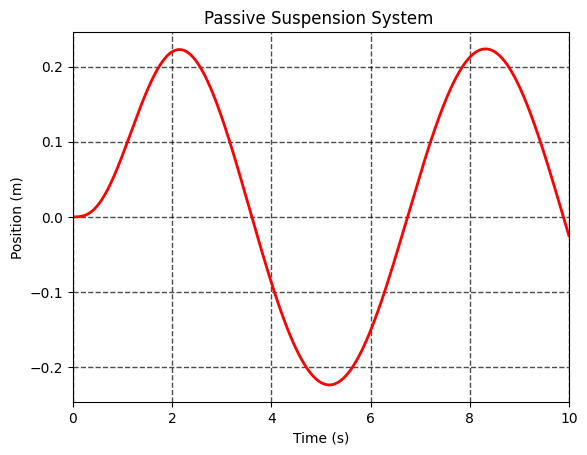

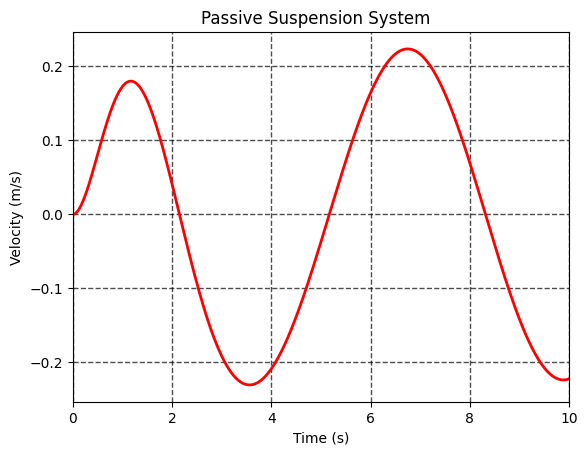

In [16]:
# System parameters
m = 1
k = 5
c = 2
g = 9.8

A = np.array([[0, 1],
              [-k/m, -c/m]])  # Corrected c instead of rho

B = np.array([[0],
              [1/m]])  # Reshaped to column vector

D = np.array([[0],
              [1/m]])  # Reshaped to column vector

C = np.array([[1, 0],[0,1]])  # Output matrix

R = np.array([0])

# flatten() to convert to 1D array since scipy.integrate.odeint requires the state vector (x) to have shape (n,), not (n,1).
x0 = np.array([0, 0]).flatten() # Initial state

# Time settings
t0 = 0  # Initial time 
tf = 10  # Final time
T = np.linspace(t0, tf, 1000)  # Time vector

def w_func(t):
    return np.sin(t)
    
def u_func(t):
    return 0.0 # Control input

# Compute system response
y = OpenLoopInputOutputSystem(A, B, D, C, R, u_func, w_func, T, x0)

# Plot the response
plt.plot(T, y[0,:], linewidth=2.0, color='red')
plt.grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlim([t0, tf])
plt.ylabel(r'Position (m)')
plt.xlabel('Time (s)')
plt.title('Passive Suspension System ')
plt.show()

plt.plot(T, y[1,:], linewidth=2.0, color='red')
plt.grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlim([t0, tf])
plt.ylabel(r'Velocity (m/s)')
plt.xlabel('Time (s)')
plt.title('Passive Suspension System  ')
plt.show()

## Ex.2: DC Motor Speed: System Modeling

A common actuator in control systems is the DC motor. It directly provides rotary motion and, coupled with wheels or drums and cables, can provide translational motion. The electric equivalent circuit of the armature and the free-body diagram of the rotor are shown in the following figure.

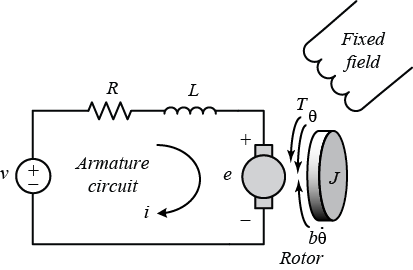

For this example, we will assume that the input of the system is the voltage source ($V$) applied to the motor's armature, while the output is the rotational speed of the shaft $\dot{\theta}$. The rotor and shaft are assumed to be rigid. We further assume a viscous friction model, that is, the friction torque is proportional to shaft angular velocity. We will assume that the magnetic field is constant and, therefore, that the motor torque is proportional (with constant $K_t$) to only the armature current. Let us remark that in SI units the motor torque and back emf constants are equal, that is, $K_t = K_e$.

The physical parameters for our example are:

    (J)   moment of inertia of the rotor     0.01 kg.m^2

    (b)     motor viscous friction constant    0.1 N.m.s

    (Ke)    electromotive force constant       0.01 V/rad/sec

    (Kt)    motor torque constant              0.01 N.m/Amp

    (R)     electric resistance                1 Ohm

    (L)     electric inductance                0.5 H

## TODO
1. Let us assume that the state vector is $x = (w,i)$ where $w = \dot\theta$ is an angular velocity of the motor. Derive the state space equations of the system. Is the system linear?

*Answer:*
State vector: $x = \begin{bmatrix} \omega \\ i \end{bmatrix}$ where $\omega = \dot{\theta}$ (angular velocity), $i$ (current)
Motor equations:
- Electrical: $L\frac{di}{dt} = V - Ri - K\omega$
- Mechanical: $J\frac{d\omega}{dt} = Ki - b\omega$
State space form:
$$\dot{x} = \begin{bmatrix} -b/J & K/J \\ -K/L & -R/L \end{bmatrix}x + \begin{bmatrix} 0 \\ 1/L \end{bmatrix}V$$
*System is linear* because equations contain no nonlinear terms (no products, powers, or transcendental functions of state variables).

2. Rewrite the system equations in canonical first order ODE system form.

*Answer:*
Standard first-order ODE form: $\dot{x} = Ax + Bu$
where:
$$A = \begin{bmatrix} -b/J & K/J \\ -K/L & -R/L \end{bmatrix}, \quad B = \begin{bmatrix} 0 \\ 1/L \end{bmatrix}$$

3. Simulate the output of the system corresponding to uncontrolled system (i.e V = 0) and a random initial position.

4. Let's assume that the motor is off. How will the system's behavior change if we apply 15 volts as an input?

*Answer:*
With 15V: motor accelerates to steady-state speed.
With V=0: motor decays to rest.

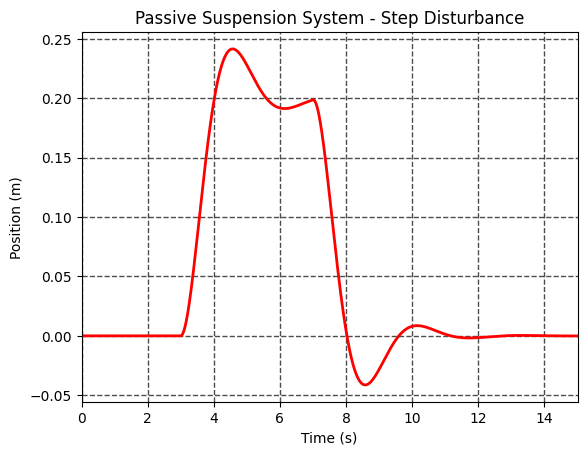

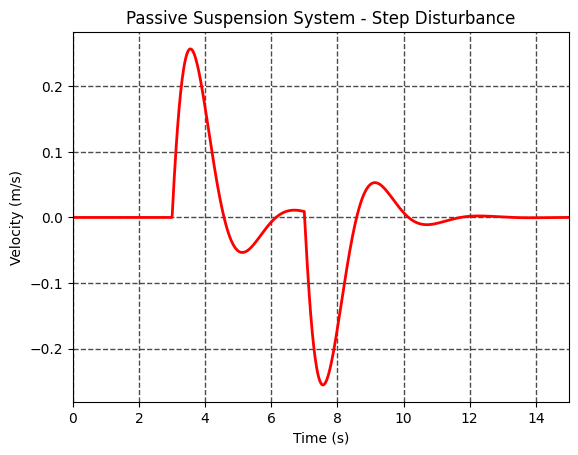

In [17]:
# System parameters
m = 1
k = 5
c = 2
g = 9.8

A = np.array([[0, 1],
              [-k/m, -c/m]])

B = np.array([[0],
              [1/m]])

D = np.array([[0],
              [1/m]])

C = np.array([[1, 0],[0,1]])

R = np.array([0])

x0 = np.array([0, 0]).flatten()

t0 = 0
tf = 15
T = np.linspace(t0, tf, 1000)

def w_func(t):
    if t < 3.0:
        return 0.0
    elif t < 7.0:
        return 1.0
    else:
        return 0.0
    
def u_func(t):
    return 0.0

y = OpenLoopInputOutputSystem(A, B, D, C, R, u_func, w_func, T, x0)

plt.plot(T, y[0,:], linewidth=2.0, color='red')
plt.grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlim([t0, tf])
plt.ylabel(r'Position (m)')
plt.xlabel('Time (s)')
plt.title('Passive Suspension System - Step Disturbance')
plt.show()

plt.plot(T, y[1,:], linewidth=2.0, color='red')
plt.grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlim([t0, tf])
plt.ylabel(r'Velocity (m/s)')
plt.xlabel('Time (s)')
plt.title('Passive Suspension System - Step Disturbance')
plt.show()

## Ex.3: Pendulum

Let us now consider the pendulum example from the lecture.

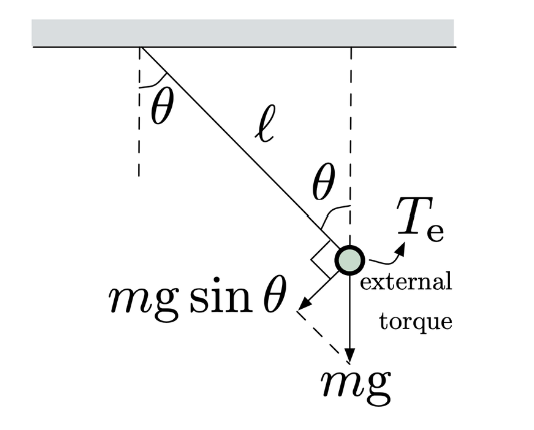

Using the free body diagram we can derive the following equation of motion.
$$ml^2*\ddot \theta = -m*g*\sin(\theta)*l +T_e$$

we then rewrite it in the canonical form
$$
\begin{aligned}
&\dot\theta_1 = \theta_2\\
&\dot\theta_2 =  -\frac{g}{l}*\sin(\theta_1) + \frac{T_e}{m*l^2}
\end{aligned}
$$
where we use the notation $\theta_1  = \theta, \theta_2 = \dot\theta_1$.

We then linearise the system around an equilibrium point ($\theta_1, \theta_2, T_e$) = (0,0,0), with a help of symbolic calculus (see the code below) and get a linear time invariant model
$$
\begin{aligned}
&\dot\theta_1 = \theta_2\\
&\dot\theta_2 =  -\frac{g}{l} + \frac{T_e}{m*l^2}
\end{aligned}
$$

## TODO
1. Let fisrt consider the system without control ($T_e = 0$). Plot the trajectories of linear and nonlinear systems for
   $\theta^0 = (0.1, 0)$ and  $\theta^0 = (1, 0).$ What kind of conclusion could you make when analyzing the simulation's result?
   
   *Answer:*
Small angle ($\theta^0 = 0.1$): Linear and nonlinear systems behave nearly identically
Large angle ($\theta^0 = 1$): Significant deviation between systems
  *Conclusion:* Linearization valid only for small angles near equilibrium point

2. Let $\theta^0 = (0, 0)$, play with different control inputs, and look at how they affect linear and nonlinear systems correspondingly. What kind of conclusion can you make from this?
*Answer:*
Small control $T_e$: Both systems respond similarly
Large control $T_e$: Nonlinear system shows different dynamics than linear approximation
*Conclusion:* Linear model accurate only within limited operating range; nonlinear effects dominate under large disturbances/inputs

In [18]:
#profite from symbolic calculus do easy the math part
import sympy as sp
m, l, g, Te = sp.symbols('m l g Te')
theta1, theta2, dottheta2 = sp.symbols('theta1 theta2 dottheta2')

# Define the differential equations of the system
eq1 = m*l*l* dottheta2 + m*g*sp.sin(theta1)*l - Te

# Solve for the first derivative of theta1 (angular velocity)
dotthet2_sol = sp.solve(eq1, dottheta2)[0]

# Solve for the first derivative of y1 (linear velocity)
dottheta2_sol = sp.simplify(sp.solve(eq1, dottheta2)[0])

# Define the state-space representation of the system dynamics
f1 = theta2
f2 = dotthet2_sol
f = sp.Matrix([f1, f2])

# Define state and control variables
variables_x = sp.Matrix([theta1,theta2])
variables_u = sp.Matrix([Te])

# Compute the Jacobian matrices of the system
jacobian_A = sp.simplify(f.jacobian(variables_x).subs([(theta1,0), (theta2,0)]))
jacobian_B = sp.simplify(f.jacobian(variables_u).subs([(theta1,0), (theta2,0)]))

In [19]:
jacobian_B

Matrix([
[         0],
[1/(l**2*m)]])

In [20]:
jacobian_A

Matrix([
[   0, 1],
[-g/l, 0]])

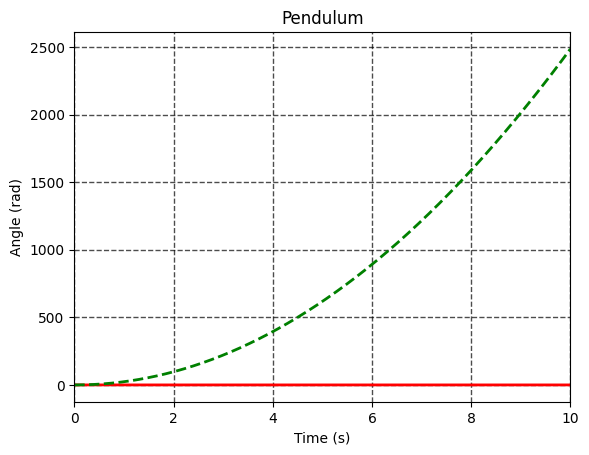

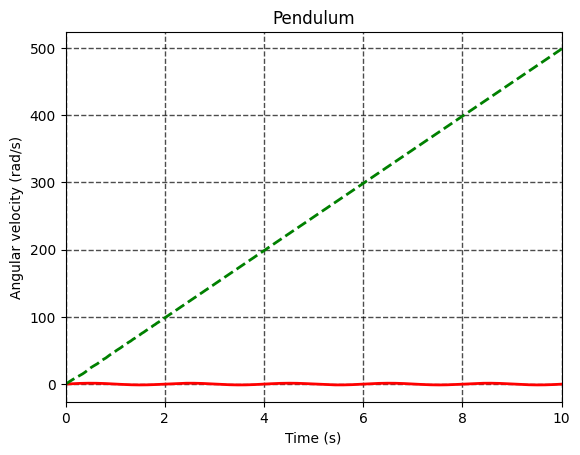

In [21]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def PendulumNonlinear(theta,t,m,l,g,Te):
    dth1 = theta[1]
    dth2 = -g/l*np.sin(theta[0]) +1/(m*l*l)*Te(t)
    return [dth1, dth2]

m = 0.1;
l = 1;
g = 9.8;

A = np.array([[0,1],[-g/l, 0]])
B = np.array([[0],
             [1]])
D = np.array([0])
C = np.array([[1,0],[0,1]])
R = np.array([0])

t0 = 0  # Initial time 
tf = 10  # Final time
T = np.linspace(t0, tf, 1000)  # Time vector

def w_func(t):
    return 0.0 # Disturbance input
    
def u_func(t):
    return 5.0 # Control input

x0 = np.array([0.1, 0]).flatten() # Initial state
# 

# Compute system response
y = OpenLoopInputOutputSystem(A, B, D, C, R, u_func, w_func, T, x0)

y1 = odeint(PendulumNonlinear, x0, T, args=(m,l,g, u_func))

# Plot the response
plt.plot(T, y[0,:], linewidth=2.0, color='red')
plt.plot(T, y1[:,0], linewidth=2.0, linestyle='--',color='green')
plt.grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlim([t0, tf])
plt.ylabel(r'Angle (rad)')
plt.xlabel('Time (s)')
plt.title('Pendulum')
plt.show()

plt.plot(T, y[1,:], linewidth=2.0, color='red')
plt.plot(T, y1[:,1], linewidth=2.0, linestyle='--',color='green')
plt.grid(color='black', linestyle='--', linewidth=1.0, alpha=0.7)
plt.xlim([t0, tf])
plt.ylabel(r'Angular velocity (rad/s)')
plt.xlabel('Time (s)')
plt.title('Pendulum')
plt.show()

## Ex 4. Dynamic modeling of an inverted pendulum on the cart

The system in this example consists of an inverted pendulum mounted to a motorized cart. The inverted pendulum system is an example commonly found in control system textbooks and research literature. Its popularity derives in part from the fact that it is unstable without control, that is, the pendulum will simply fall over if the cart isn't moved to balance it. Additionally, the dynamics of the system are nonlinear. The objective of the control system is to balance the inverted pendulum by applying a force to the cart that the pendulum is attached to. A real-world example that relates directly to this inverted pendulum system is the attitude control of a booster rocket at takeoff.

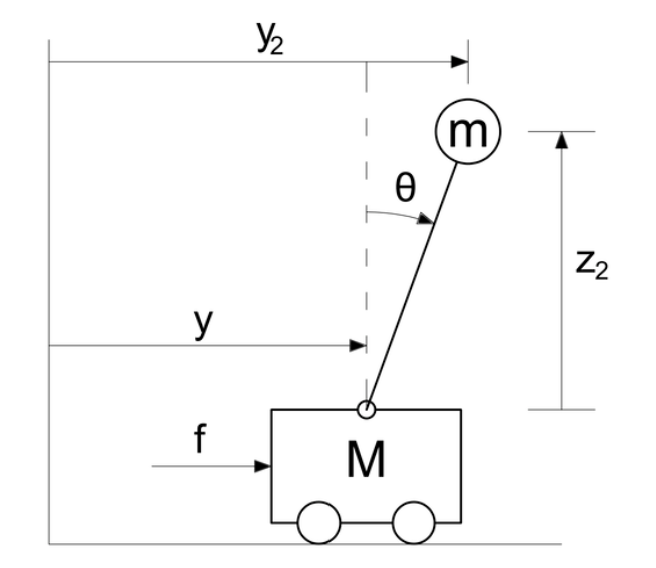

Let us consider the system with the following system parameters
    
    (M)       mass of the cart                         0.5 kg
    
    (m)       mass of the pendulum                     0.2 kg
    
    (l)       length to pendulum center of mass        0.3 m
    
    (b)       coefficient of friction for cart         0.1 N/m/sec
    
    (I)       mass moment of inertia of the pendulum   0.006 kg.m^2
    
    (F)       force applied to the cart
    
    (y)       cart position coordinates
    
    (theta)   angle between the pendulum and the vertical axis

## TODO
1) Show that the inverted pendulum on the cart can be modeled as follows

$$(M+m)\ddot{y} + b\dot{y} + ml\ddot{\theta}\cos\theta -ml\dot\theta^2\sin(\theta) = F$$
$$ml\cos(\theta)\ddot{y} + (I+ml^2)\ddot{\theta} - mgl\sin\theta = 0$$

If you find it difficult to derive the equations yourself, please, watch the following video: 
https://www.youtube.com/watch?v=kXLjs5aW2uE

*Answer:*
Apply Lagrangian mechanics or Newton's second law to cart and pendulum separately.
Equations derived from force balance and torque balance yield the given coupled nonlinear ODEs.
See reference videos/tutorials for detailed derivation steps.

or, alternatively, check the following tutorial https://ctms.engin.umich.edu/CTMS/index.php?example=InvertedPendulum&section=SystemModeling

2) Rewrite the system equation in a canonical form $\dot x = f(x,u),$ where state vector $x = (y,\theta,\dot y,\dot\theta)$.

*Answer:*
State vector: $x = [y, \theta, \dot{y}, \dot{\theta}]^T$
System: $\dot{x} = f(x,u)$ where:
$$\dot{x}_1 = x_3$$
$$\dot{x}_2 = x_4$$
$$\dot{x}_3 = \frac{1}{(M+m)-m\cos^2(x_2)}[F + ml\sin(x_2)x_4^2 - b x_3 - ml\cos(x_2)\frac{mgl\sin(x_2)}{I+ml^2}]$$
$$\dot{x}_4 = \frac{mgl\sin(x_2) - ml\cos(x_2)[\dot{x}_3]}{I+ml^2}$$

3) Find an equlibrium point. Linearise the system equations by finding the Jacobian matrix.

*Answer:*
Equilibrium point: $x_e = [0, 0, 0, 0]^T$ (upright position)

Jacobian at equilibrium:
$$A = \begin{bmatrix} 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & -\frac{mg}{M} & -\frac{b}{M} & 0 \\ 0 & \frac{(M+m)g}{Ml} & \frac{b}{Ml} & 0 \end{bmatrix}, \quad B = \begin{bmatrix} 0 \\ 0 \\ \frac{1}{M} \\ -\frac{1}{Ml} \end{bmatrix}$$

4) Simulate trajectories of the uncontrolled nonlinear system and its linear approximation for different initial vectors. What can you say about system dynamics?


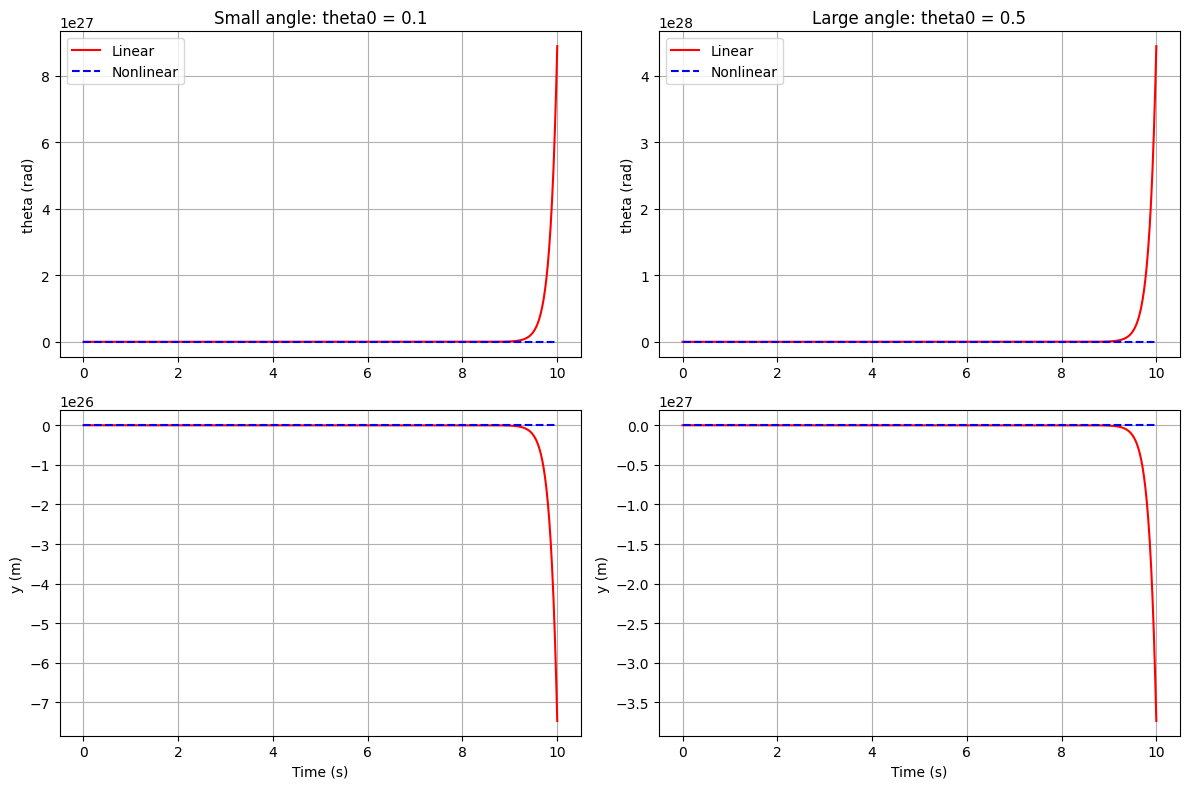

In [22]:
M = 0.5
m = 0.2
l = 0.3
b = 0.1
I = 0.006
g = 9.8

def inverted_pendulum(x, t, F):
    y, theta, ydot, thetadot = x
    
    sint = np.sin(theta)
    cost = np.cos(theta)
    
    det = (M + m) - m * cost**2
    
    yddot = (F + m * l * sint * thetadot**2 - b * ydot - m * l * cost * (m * g * l * sint / (I + m * l**2))) / det
    thetaddot = (m * g * l * sint - m * l * cost * yddot) / (I + m * l**2)
    
    return [ydot, thetadot, yddot, thetaddot]

A = np.array([[0, 0, 1, 0],
              [0, 0, 0, 1],
              [0, -m*g/M, -b/M, 0],
              [0, (M+m)*g/(M*l), b/(M*l), 0]])

B = np.array([[0], [0], [1/M], [-1/(M*l)]])
D = np.zeros((4, 1))
C = np.eye(4)
R = 0

t0 = 0
tf = 10
T = np.linspace(t0, tf, 1000)

def u_func(t):
    return 0.0

def w_func(t):
    return 0.0

x0_small = np.array([0, 0.1, 0, 0])
x0_large = np.array([0, 0.5, 0, 0])

y_linear_small = OpenLoopInputOutputSystem(A, B, D, C, R, u_func, w_func, T, x0_small)
y_nonlinear_small = odeint(inverted_pendulum, x0_small, T, args=(0,))

y_linear_large = OpenLoopInputOutputSystem(A, B, D, C, R, u_func, w_func, T, x0_large)
y_nonlinear_large = odeint(inverted_pendulum, x0_large, T, args=(0,))

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(T, y_linear_small[1,:], 'r-', label='Linear')
plt.plot(T, y_nonlinear_small[:,1], 'b--', label='Nonlinear')
plt.ylabel('theta (rad)')
plt.title('Small angle: theta0 = 0.1')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(T, y_linear_large[1,:], 'r-', label='Linear')
plt.plot(T, y_nonlinear_large[:,1], 'b--', label='Nonlinear')
plt.ylabel('theta (rad)')
plt.title('Large angle: theta0 = 0.5')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(T, y_linear_small[0,:], 'r-')
plt.plot(T, y_nonlinear_small[:,0], 'b--')
plt.ylabel('y (m)')
plt.xlabel('Time (s)')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(T, y_linear_large[0,:], 'r-')
plt.plot(T, y_nonlinear_large[:,0], 'b--')
plt.ylabel('y (m)')
plt.xlabel('Time (s)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Conclusion: Linearization valid only for small angles. System unstable - pendulum falls without control.**